In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Business Problem: Flight Price Prediction

**Objective:**
- A travel agency wants to predict flight prices based on various factors like the airline, source, destination, journey date, number of stops, and flight duration. By doing so, the agency aims to optimize their pricing strategy to increase competitiveness in the market.

**Problem Details:**
- **Goal: Predict the Price of a flight ticket.**

**Inputs:**
  
- Airline: Airline operating the flight.
- Date_of_Journey: Date when the flight departs.
- Source: Departure city.
- Destination: Arrival city.
- Route: The flight path (list of stops).
- Dep_Time: Time of departure.
- Arrival_Time: Time of arrival.
- Duration: Duration of the flight.
- Total_Stops: Number of stops the flight makes.
- Additional_Info: Extra details like "No info" or specific flight information.

**Output:**
- Price: Cost of the flight ticket.

In [3]:
df = pd.read_excel(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\ML_data\ML Live Flight Fare.xlsx")

# Data Understanding

In [4]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [5]:
df.shape

(10683, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


**Observation**

- The dataset contains 10,683 records and 11 columns.
- Price is the only numerical column, while the other columns are of object (string) type.
- There are no missing values in most of the columns, but Route and Total_Stops have 1 missing value each. This might need handling before model training.



In [7]:
df.columns.tolist()

['Airline',
 'Date_of_Journey',
 'Source',
 'Destination',
 'Route',
 'Dep_Time',
 'Arrival_Time',
 'Duration',
 'Total_Stops',
 'Additional_Info',
 'Price']

- all columns are in correct syntax

In [8]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

**Observation**

- The Date_of_Journey, Dep_Time, and Arrival_Time are in string format, which will need to be converted into datetime for proper analysis.
- Duration is stored as a string (e.g., "2h 50m"), which will need conversion into a numerical value (like total minutes).
- The Total_Stops column is also stored as a string (e.g., "1 stop", "non-stop"), which should be converted into numerical values for better modeling.


In [9]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

**Observation:**

 **Columns with Missing Values:**

- Route has 1 missing value.

- Total_Stops also has 1 missing value.

In [11]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


<Axes: xlabel='Price', ylabel='Count'>

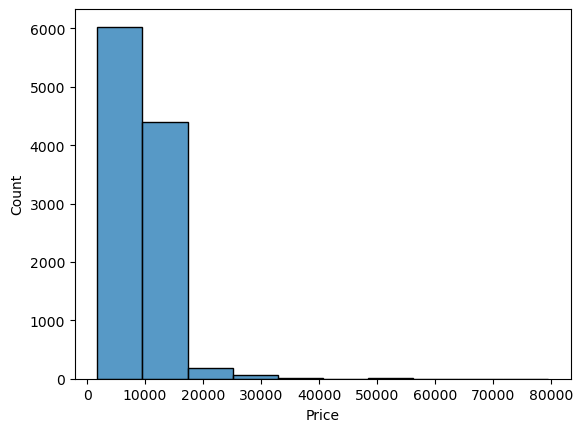

In [12]:
# df['Price'].hist()
sns.histplot( df['Price'], bins = 10)

In [13]:
df.nunique()

Airline              12
Date_of_Journey      44
Source                5
Destination           6
Route               128
Dep_Time            222
Arrival_Time       1343
Duration            368
Total_Stops           5
Additional_Info      10
Price              1870
dtype: int64

 **Outliers Detection**

<Axes: ylabel='Price'>

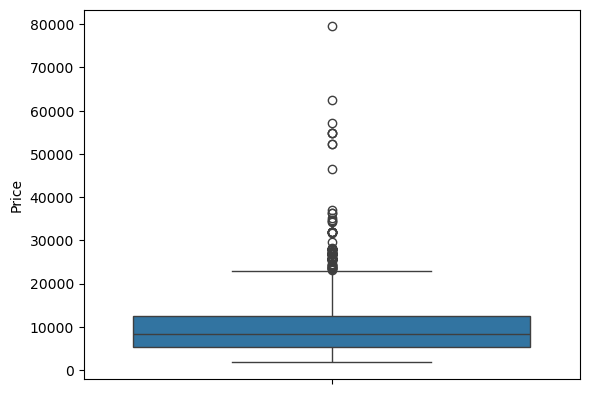

In [14]:
sns.boxplot(df["Price"])

In [15]:
df['Price'].skew()

1.8125523782189141

<Axes: xlabel='Price', ylabel='Density'>

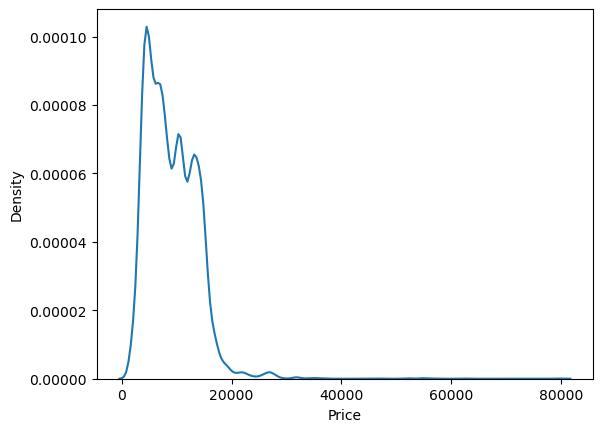

In [16]:
sns.kdeplot(df['Price'])

**Observation on Skewness:**
- Skewness value of 1.81 indicates a positively skewed distribution (right skew).
- Positive skewness means that the right tail (higher values) of the data is longer or more spread out than the left tail (lower values).
- Positively Skewed Data may require transformation before model building to reduce the skewness:

**Date and Time Analysis**

In [17]:
df[['Date_of_Journey','Dep_Time', 'Arrival_Time']].dtypes

Date_of_Journey    object
Dep_Time           object
Arrival_Time       object
dtype: object

**Observation**
- Convert the Date_of_Journey, Dep_Time, and Arrival_Time columns to datetime and extract useful features like day, month, hour

- **Duration Handling**
- Convert Duration from string format (e.g., "2h 50m", "19h") to total minutes.

In [18]:
# Find value counts for all categorical columns
for column in df.select_dtypes(include=['object']).columns:
    print(f"Value counts for {column}:")
    print("--------------------------------------")
    print(df[column].value_counts())
    print("\n")

Value counts for Airline:
--------------------------------------
Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64


Value counts for Date_of_Journey:
--------------------------------------
Date_of_Journey
18/05/2019    504
6/06/2019     503
21/05/2019    497
9/06/2019     495
12/06/2019    493
9/05/2019     484
21/03/2019    423
15/05/2019    405
27/05/2019    382
27/06/2019    355
24/06/2019    351
1/06/2019     342
3/06/2019     333
15/06/2019    328
24/03/2019    323
6/03/2019     308
27/03/2019    299


In [20]:
df["Arrival_Time"]

0        01:10 22 Mar
1               13:15
2        04:25 10 Jun
3               23:30
4               21:35
             ...     
10678           22:25
10679           23:20
10680           11:20
10681           14:10
10682           19:15
Name: Arrival_Time, Length: 10683, dtype: object